In [8]:
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd

<p style="font-size:26px;">Шаг 1. Получение общей информации о данных.</p>

In [9]:
# Чтение таблиц из бд
df_Users = pd.read_csv('users.csv')
df_Orders = pd.read_csv('orders.csv')
df_Products = pd.read_csv('products.csv')
df_ShippingAddresses = pd.read_csv('shipping_addresses.csv')
df_OrderDetails = pd.read_csv('order_details.csv')

# Первичный осмотр эллементов таблицы
df_Users.head(5), df_Orders.head(5), df_Products.head(5), df_ShippingAddresses.head(5), df_OrderDetails.head(5)

(     user_id       user_name      segment
 0  GH-100000       Gene Hale    Corporate
 1  NP-100001  Nora Pelletier  Home Office
 2  IM-100002    Irene Maddox     Consumer
 3  LC-100003    Liz Carlisle     Consumer
 4  DB-100004    David Bremer    Corporate,
        order_id    user_id
 0  AE-2011-9160  PO-100330
 1  AE-2013-1130  EB-100464
 2  AE-2013-1530  MY-100114
 3  AE-2014-2840  PG-100669
 4  AE-2014-3830  GH-100773,
          product_id                       product_name   category sub_category
 0  FUR-ADV-10000002     Advantus Photo Frame, Duo Pack  Furniture  Furnishings
 1  FUR-ADV-10000108          Advantus Clock, Erganomic  Furniture  Furnishings
 2  FUR-ADV-10000183        Advantus Photo Frame, Black  Furniture  Furnishings
 3  FUR-ADV-10000188  Advantus Stacking Tray, Erganomic  Furniture  Furnishings
 4  FUR-ADV-10000190           Advantus Frame, Duo Pack  Furniture  Furnishings,
    shipping_id    user_id        order_id  market        country        state  \
 0       

<p style="font-size:26px;">В таблице df_Users в колонке segment мы видим значение Consumer, что означает - потребитель. Для улучшения читаемости таблицы меняем значения Consumer на Individual, что будет более точно отражать данный сегмент покупателей. Так же эту колонку имеет смысл проверить на наличие других уникальных значений.</p>

In [10]:
# Изменение значений Consumer на Individual
df_Users['segment'] = df_Users['segment'].replace('Consumer', 'Individual')

# Вывод уникальных значений
df_Users['segment'].unique()

<StringArray>
['Corporate', 'Home Office', 'Individual']
Length: 3, dtype: str

In [11]:
# Вывод общей информации по таблицам
df_Users.info(), df_Orders.info(), df_Products.info(), df_ShippingAddresses.info(), df_OrderDetails.info()

<class 'pandas.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    795 non-null    str  
 1   user_name  795 non-null    str  
 2   segment    795 non-null    str  
dtypes: str(3)
memory usage: 18.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 25035 entries, 0 to 25034
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   order_id  25035 non-null  str  
 1   user_id   25035 non-null  str  
dtypes: str(2)
memory usage: 391.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 10292 entries, 0 to 10291
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    10292 non-null  str  
 1   product_name  10292 non-null  str  
 2   category      10292 non-null  str  
 3   sub_category  10292 non-null  str  
dtypes: str(4)
memory usage: 321.8 KB
<class 'pandas.D

(None, None, None, None, None)

<p style="font-size:26px;">В таблице df_OrderDetails мы видим, что колонки order_date и ship_date типа object, что не позволит нам работать с датами, поэтому приводим данные к типу datetime.</p>

In [12]:
# Преобразование обоих колонок с датой к типу datetime
df_OrderDetails['order_date'] = pd.to_datetime(df_OrderDetails['order_date'])
df_OrderDetails['ship_date'] = pd.to_datetime(df_OrderDetails['ship_date'])
df_OrderDetails.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_detail_id  51290 non-null  int64         
 1   order_id         51290 non-null  str           
 2   product_id       51290 non-null  str           
 3   order_date       51290 non-null  datetime64[us]
 4   ship_date        51290 non-null  datetime64[us]
 5   ship_mode        51290 non-null  str           
 6   shipping_cost    51290 non-null  float64       
 7   discount         51290 non-null  float64       
 8   order_priority   51290 non-null  str           
 9   quantity         51290 non-null  int64         
 10  profit           51290 non-null  float64       
 11  sales            51290 non-null  float64       
dtypes: datetime64[us](2), float64(4), int64(2), str(4)
memory usage: 4.7 MB


<p style="font-size:26px;">В каждом df_info() мы видим отсутсвие пустых строк. В случае их наличия для удобного подсчета и возможных действий с ними можно использовать df.isna().sum(), но в нашем случае это не имеет смысла.</p>

<p style="font-size:26px;">Теперь нужно проверить наличие явных дубликатов в таблице df_OrderDetails, чтобы избежать искажения агрегатов и нужно проверить наличие неявных дубликатов для пар значений в колонках user_id, user_name, чтобы иметь корректное колличество уникальных сущностей.</p>

In [13]:
df_OrderDetails[df_OrderDetails.duplicated(keep=False)]

,order_detail_id,order_id,product_id,order_date,ship_date,ship_mode,shipping_cost,discount,order_priority,quantity,profit,sales


In [14]:
DuplicatedName = df_Users.groupby('user_name')['user_id'].nunique()
DuplicatedName[DuplicatedName > 1]

Series([], Name: user_id, dtype: int64)

<p style="font-size:26px;">Шаг 2. Анализ числовых и категоральных столбцов.</p>

In [15]:
# Объединение нужных для анализа таблиц
df_Full = pd.merge(df_OrderDetails, df_Orders, on='order_id', how='inner')
df_Full = pd.merge(df_Full, df_Users, on='user_id', how='inner')
df_Full


,order_detail_id,order_id,product_id,order_date,ship_date,ship_mode,shipping_cost,discount,order_priority,quantity,profit,sales,user_id,user_name,segment
0,1,CA-2011-130813,OFF-PA-10002005,2011-01-07,2011-01-09,Second Class,4.37,0.0,High,3,9.3312,19.0,LS-100780,Lycoris Saunders,Individual
1,2,CA-2011-148614,OFF-PA-10002893,2011-01-21,2011-01-26,Standard Class,0.94,0.0,Medium,2,9.2928,19.0,MV-100690,Mark Van Huff,Individual
2,3,CA-2011-118962,OFF-PA-10000659,2011-08-05,2011-08-09,Standard Class,1.81,0.0,Medium,3,9.8418,21.0,CS-100364,Chad Sievert,Individual
3,4,CA-2011-118962,OFF-PA-10001144,2011-08-05,2011-08-09,Standard Class,4.59,0.0,Medium,2,53.2608,111.0,CS-100364,Chad Sievert,Individual
4,5,CA-2011-146969,OFF-PA-10002105,2011-09-29,2011-10-03,Standard Class,1.32,0.0,High,1,3.1104,6.0,AP-100362,Arthur Prichep,Individual
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,51286,CA-2014-109701,OFF-BI-10000632,2014-12-03,2014-12-04,Same Day,5.15,0.2,High,2,22.5732,69.0,AM-100320,Alice McCarthy,Corporate
51286,51287,CA-2014-109701,OFF-BI-10004187,2014-12-03,2014-12-04,Same Day,0.44,0.2,High,6,3.1584,9.0,AM-100320,Alice McCarthy,Corporate
51287,51288,CA-2014-106964,OFF-BI-10000320,2014-12-18,2014-12-21,First Class,0.31,0.2,Medium,2,4.2804,12.0,HR-100702,Hallie Redmond,Home Office
51288,51289,CA-2014-145219,OFF-BI-10001670,2014-12-25,2014-12-26,First Class,15.95,0.2,Critical,3,33.9300,90.0,RM-100079,Robert Marley,Home Office


<p style="font-size:26px;">Мы видим, что финальный размер колонок равен изначальному размеру колонок в df_OrderDetails. Это значит, что при объединении мы не потеряли никаких значений.</p>

<p style="font-size:26px;">Теперь выведем и проанализируем основные статистические показатели.</p>

In [16]:
# Основные статистические показатели
print("Статистические показатели sales:")
print(df_Full['sales'].describe())

Статистические показатели sales:
count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64


<p style="font-size:26px;">Мы видим, что минимальное значение выручки равно 0. Это значит, что есть позиции, которые не принисли нам выручки, тоесть прибыль этих товаров <= 0. Найдем такие товары и выведем их количество.</p>

In [17]:
# Вывод всех строк с нулевой выручкой и их количества.
ZeroSales = df_Full[df_Full['sales'] == 0]
print(ZeroSales.head(10)) 
print('Число строк с нулевой выручкой:', df_Full[df_Full['sales'] == 0].shape[0])

       order_detail_id        order_id       product_id order_date  ship_date  \
46158            46159  US-2014-102288  OFF-AP-10002906 2014-06-20 2014-06-24   

            ship_mode  shipping_cost  discount order_priority  quantity  \
46158  Standard Class           0.01       0.8         Medium         1   

       profit  sales    user_id         user_name     segment  
46158   -1.11    0.0  ZC-100147  Zuschuss Carroll  Individual  
Число строк с нулевой выручкой: 1


<p style="font-size:26px;">Мы видим, что у нас есть всего одна строка с нулевой выручкой. Ее удаление не повлияет на наши целевые метрики, но позволит нам более качественно оценить минимальную выручку.</p>

In [18]:
# Удаление строки с нулевой выручкой
df_Full.drop(df_Full[df_Full['sales'] == 0].index, inplace=True)

# Повторный вывод статистических показателей
print("Статистические показатели sales:")
print(df_Full['sales'].describe())

Статистические показатели sales:
count    51289.000000
mean       246.503246
std        487.570713
min          1.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64


<p style="font-size:26px;">Теперь проанализируем распределение выручки по позициям.</p>

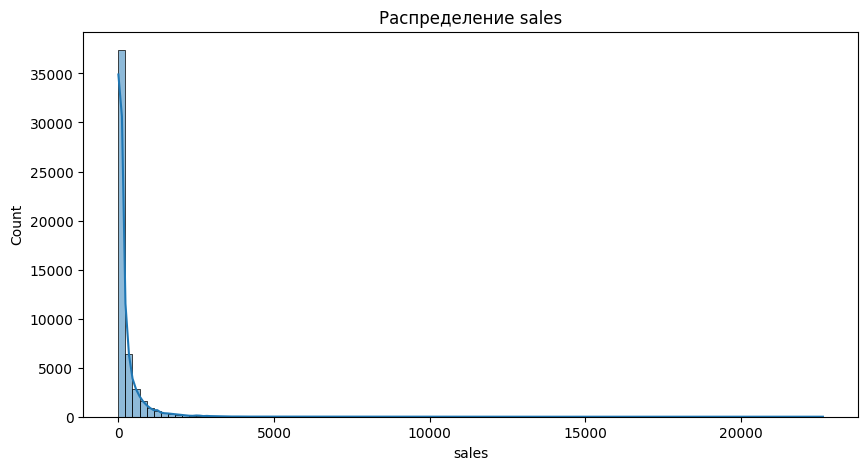

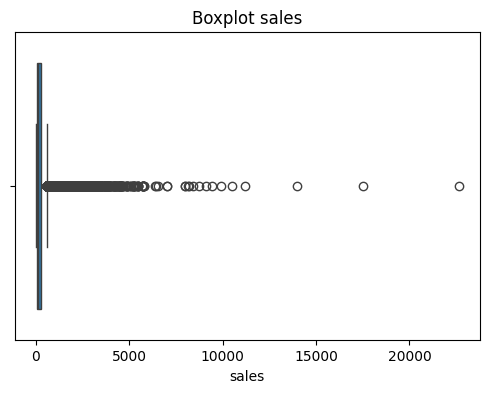

In [19]:
# Построение гистограммы 
plt.figure(figsize=(10, 5))
sns.histplot(df_Full['sales'], bins=100, kde=True)
plt.title('Распределение sales')
plt.xlabel('sales')
plt.show()

# Построение диаграммы размаха
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_Full['sales'])
plt.title('Boxplot sales')
plt.show()

<p style="font-size:26px;">На boxplot мы видим выбросы, которые могут сильно влиять на ключевые метрики, в нашем случае эти выбросы скорее всего являются не ошибками в данных, а крупными сделки, поэтому мы не можем их просто удалить, но стоит на время отделить их от остальной таблицы для более корректного расчета ключевых метрик.</p>

In [20]:
BigSales = df_Full[df_Full['sales'] > 12000]
BigSales

,order_detail_id,order_id,product_id,order_date,ship_date,ship_mode,shipping_cost,discount,order_priority,quantity,profit,sales,user_id,user_name,segment
27734,27735,CA-2013-118689,TEC-CO-10004722,2013-10-03,2013-10-10,Standard Class,349.07000,0.0,Medium,5,8399.9760,17500.0,TC-100622,Tamara Chand,Corporate
28335,28336,CA-2014-140151,TEC-CO-10004722,2014-03-24,2014-03-26,First Class,20.00054,0.0,Medium,4,6719.9808,14000.0,RB-100278,Raymond Buch,Individual
47257,47258,CA-2011-145317,TEC-MA-10002412,2011-03-18,2011-03-23,Standard Class,24.28650,0.5,Medium,6,-1811.0784,22638.0,SM-100644,Sean Miller,Home Office


<p style="font-size:26px;">Вывев выбросы отдельно мы видим у одного заказа отрицательную прибыль при самой большой выручке, имеет смысл посмотреть другие заказы с этим товаром.</p>

In [21]:
tec_sales = df_Full[df_Full['product_id'] == 'TEC-MA-10002412']
tec_sales.head(10)

,order_detail_id,order_id,product_id,order_date,ship_date,ship_mode,shipping_cost,discount,order_priority,quantity,profit,sales,user_id,user_name,segment
47257,47258,CA-2011-145317,TEC-MA-10002412,2011-03-18,2011-03-23,Standard Class,24.2865,0.5,Medium,6,-1811.0784,22638.0,SM-100644,Sean Miller,Home Office


<p style="font-size:26px;">Мы видим, что этот товар продавался один раз и продавался со скидкой 50%. Наиболее вероятно, что этот товар мог быть частным заказом от партнера, что обьясняло бы скидку. На общий анализ наших ключевых метрик он никак не влияет.</p>

In [22]:
df2_Full = df_Full[df_Full['sales'] < 12000]
df2_Full['sales'].describe()

count    51286.000000
mean       245.462056
std        467.406484
min          1.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      11200.000000
Name: sales, dtype: float64

<p style="font-size:26px;">Теперь нас интересует категоральный столбец segment, анализ которого требуется для подтверждения нашей гипотезы.</p>

In [23]:
# Частота каждого сегмента
print(df2_Full['segment'].value_counts())

segment
Individual     26523
Corporate      15500
Home Office     9263
Name: count, dtype: int64


<p style="font-size:26px;">Шаг 3. Расчет ключевых метрик необходимых для сравнения сегментов.</p>

In [24]:
# Расчет суммы каждого заказа
OrderTotals = df2_Full.groupby(['order_id', 'segment'])['sales'].sum().reset_index()
OrderTotals.head(10)

,order_id,segment,sales
0,AE-2011-9160,Individual,161.0
1,AE-2013-1130,Individual,229.0
2,AE-2013-1530,Corporate,24.0
3,AE-2014-2840,Individual,42.0
4,AE-2014-3830,Individual,280.0
5,AE-2014-4120,Individual,6.0
6,AG-2011-1070,Corporate,309.0
7,AG-2011-1390,Home Office,607.0
8,AG-2011-1440,Individual,59.0
9,AG-2011-2040,Individual,408.0


<p style="font-size:26px;">Расчет среднего чека (AOV) для каждого сегмента.</p>

In [25]:
AOV = OrderTotals.groupby('segment')['sales'].mean().reset_index()
AOV.columns = ['segment', 'avg_order_value']
AOV


,segment,avg_order_value
0,Corporate,504.583189
1,Home Office,497.950942
2,Individual,503.563688


<p style="font-size:26px;">Расчет частоты покупок (PF) для каждого сегмента.</p>

In [26]:
PF = df2_Full.groupby('segment').agg(orders=('order_id', 'nunique'), users=('user_id', 'nunique')).reset_index()
PF['purchase_frequency'] = PF['orders'] / PF['users']
PF

,segment,orders,users,purchase_frequency
0,Corporate,7531,238,31.642857
1,Home Office,4566,148,30.851351
2,Individual,12938,409,31.633252


<p style="font-size:26px;">Расчет пожизненной ценности (LTV) для каждого сегмента.</p>

In [27]:
LTV = df2_Full.groupby('segment').agg(total_sales=('sales', 'sum'), users=('user_id', 'nunique')).reset_index()
LTV['lifetime_value'] = LTV['total_sales'] / LTV['users']
LTV

,segment,total_sales,users,lifetime_value
0,Corporate,3800016.0,238,15966.453782
1,Home Office,2273644.0,148,15362.459459
2,Individual,6515107.0,409,15929.356968


<p style="font-size:26px;">Объединение всех метрик в одну таблицу.</p>

In [28]:
metrics = AOV.merge(PF[['segment', 'purchase_frequency']], on='segment').merge(LTV[['segment', 'lifetime_value']], on='segment')
metrics


,segment,avg_order_value,purchase_frequency,lifetime_value
0,Corporate,504.583189,31.642857,15966.453782
1,Home Office,497.950942,30.851351,15362.459459
2,Individual,503.563688,31.633252,15929.356968


<p style="font-size:26px;">Визуализация для сравнения сегментов.</p>

C:\Users\Absolutely\AppData\Local\Temp\ipykernel_17196\287618325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=OrderTotals, x='segment', y='sales', palette='Set2')


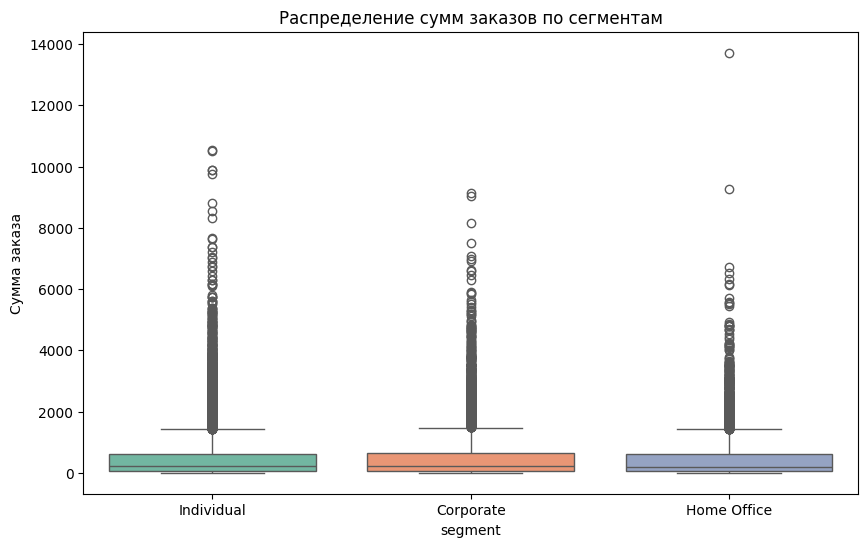

In [29]:
# Распределение сумм заказов по сегментам
plt.figure(figsize=(10,6))
sns.boxplot(data=OrderTotals, x='segment', y='sales', palette='Set2')
plt.title('Распределение сумм заказов по сегментам')
plt.ylabel('Сумма заказа')
plt.show()

C:\Users\Absolutely\AppData\Local\Temp\ipykernel_17196\2775238223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=metrics, x='segment', y='avg_order_value', palette='Set2')


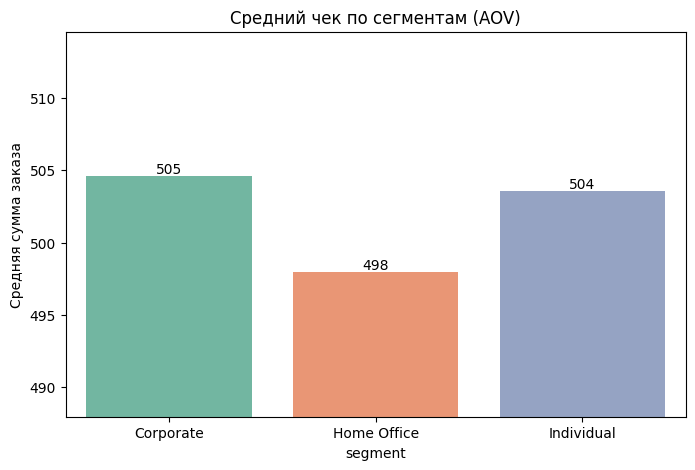

In [30]:
# Столбчатая диаграмма среднего чека
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=metrics, x='segment', y='avg_order_value', palette='Set2')

y_min = metrics['avg_order_value'].min() - 10
y_max = metrics['avg_order_value'].max() + 10

ax.set_ylim(y_min, y_max)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)
    
plt.title('Средний чек по сегментам (AOV)')
plt.ylabel('Средняя сумма заказа')
plt.show()

C:\Users\Absolutely\AppData\Local\Temp\ipykernel_17196\344088368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=metrics, x='segment', y='purchase_frequency', palette='Set2')


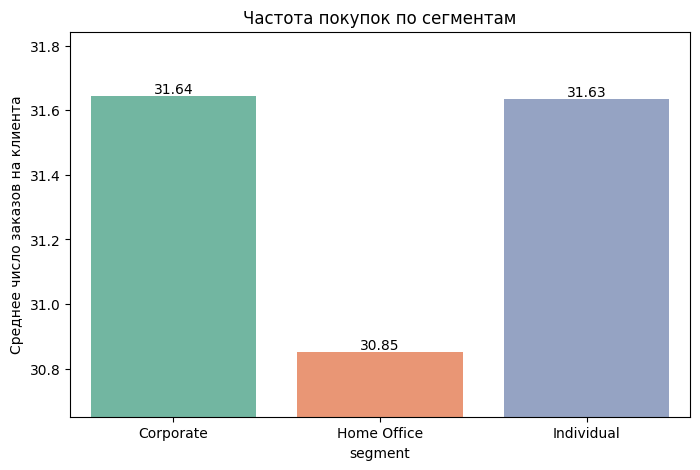

In [31]:
# Столбчатая диаграмма частоты покупок
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=metrics, x='segment', y='purchase_frequency', palette='Set2')
y_min = metrics['purchase_frequency'].min() - 0.2
y_max = metrics['purchase_frequency'].max() + 0.2
ax.set_ylim(y_min, y_max)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title('Частота покупок по сегментам')
plt.ylabel('Среднее число заказов на клиента')
plt.show()

C:\Users\Absolutely\AppData\Local\Temp\ipykernel_17196\1540206030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=metrics, x='segment', y='lifetime_value', palette='Set2')


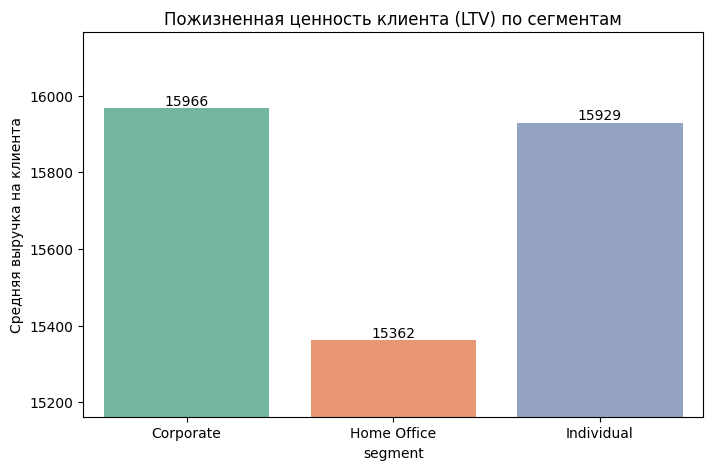

In [32]:
# Столбчатая диаграмма пожизненной ценности клиента
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=metrics, x='segment', y='lifetime_value', palette='Set2')
y_min = metrics['lifetime_value'].min() - 200
y_max = metrics['lifetime_value'].max() + 200
ax.set_ylim(y_min, y_max)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Пожизненная ценность клиента (LTV) по сегментам')
plt.ylabel('Средняя выручка на клиента')
plt.show()

In [33]:
# <p style="font-size:26px;"></p>
# Гипотеза: Клиенты из сегмента Corporate имеют более высокий средний чек и частоту покупок, чем клиенты из Individual и Home Office.
# Метрики:

# Средний чек (AOV) = SUM(sales) / COUNT(DISTINCT order_id) по сегментам

# Частота покупок = COUNT(order_id) / COUNT(DISTINCT customer_id)

# Пожизненная ценность (LTV) = SUM(sales) per customer